# K-Means Clustering Notebook

#### Importing needed packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

#### Reading the cleaned dataset

In [2]:
sys.path.append('..')

from src.data import load_data
df = load_data('../data/cleaned_log_data.csv')
df.head()

,Unnamed: 0,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718


In [3]:
df.shape

(395, 9)

#### Transform data to numpy nd array

In [8]:
features = ['Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen']

X_data = np.asanyarray(df[features])
X_data

array([[ 9.44699227,  9.17543832,  8.93089098,  5.37063803,  7.89170466,
         7.19967835],
       [ 8.861917  ,  9.19125948,  9.16628399,  7.47477218,  8.09985791,
         7.48268183],
       [ 8.75683981,  9.08352921,  8.94702566,  7.7857209 ,  8.16536363,
         8.96763167],
       ...,
       [10.57717155,  7.26682735,  6.63987583,  8.41427414,  4.54329478,
         7.7608932 ],
       [ 9.58410839,  9.64788537, 10.3170531 ,  6.08221891,  9.60521628,
         7.53262362],
       [ 9.23902501,  7.59186171,  7.71110125,  6.94601399,  5.12989871,
         7.66199756]], shape=(395, 6))

#### Visualizing the pattern of scaled data

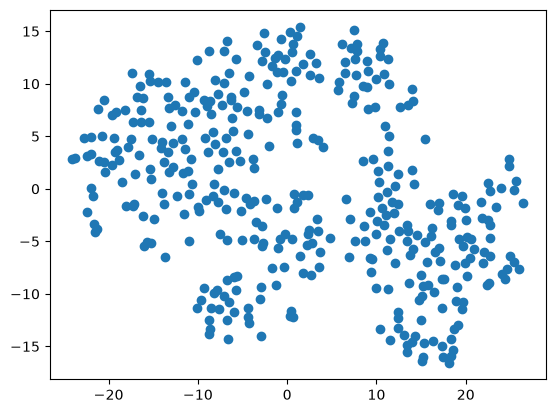

In [9]:
from src.clustering import tsne_model
from sklearn.preprocessing import StandardScaler
X_s = StandardScaler().fit_transform(X_data)
model = tsne_model(X_s)
plt.scatter(model[:,0] , model[:,1])

#### Model Training

K : 2, Score : 0.28978511717275945
K : 3, Score : 0.22120461527114238
K : 4, Score : 0.19993098282405153
K : 5, Score : 0.19531161900550845
K : 6, Score : 0.20114339426848463
K : 7, Score : 0.18767542745717616
K : 8, Score : 0.18762615622115242
K : 9, Score : 0.1773673218639021
K : 10, Score : 0.18062300226482073
K : 11, Score : 0.18199506820415573
K : 12, Score : 0.1597335661764586
K : 13, Score : 0.17301218686407216
K : 14, Score : 0.16911300164028203
K : 15, Score : 0.16499513830410678
K : 16, Score : 0.16951995090179753
K : 17, Score : 0.16747950806323997
K : 18, Score : 0.17082851649734354
K : 19, Score : 0.17222955409515808
K : 20, Score : 0.15598838829421985
K : 21, Score : 0.16904879658586816
K : 22, Score : 0.16270873610116848
K : 23, Score : 0.1615360668944399
K : 24, Score : 0.16531816072475425
K : 25, Score : 0.16549001145337783
K : 26, Score : 0.16057222318967077
K : 27, Score : 0.1534575368509464
K : 28, Score : 0.16228738410718072
K : 29, Score : 0.1650394318912214
K : 3

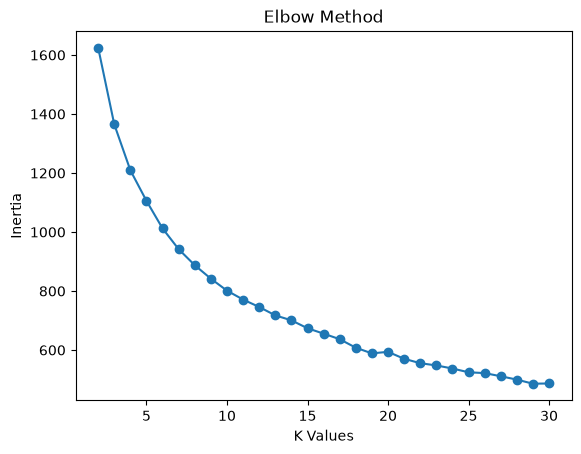

In [10]:
from src.clustering import kmeans_pipeline
model = kmeans_pipeline(X_data)

labels = model.predict(X_data)

#### This Elbow method plot indicates that the data lacks a distinct structure (specifically, a circular one) suitable for the K-Means algorithm; consequently, this algorithm is not appropriate for the project without dimensionality reduction. This outcome may be attributed to the failure to employ dimensionality reduction techniques.

#### Visualizing K-Means clustering result using t-SNE

Text(0.5, 1.0, 'K-Means Clustering')

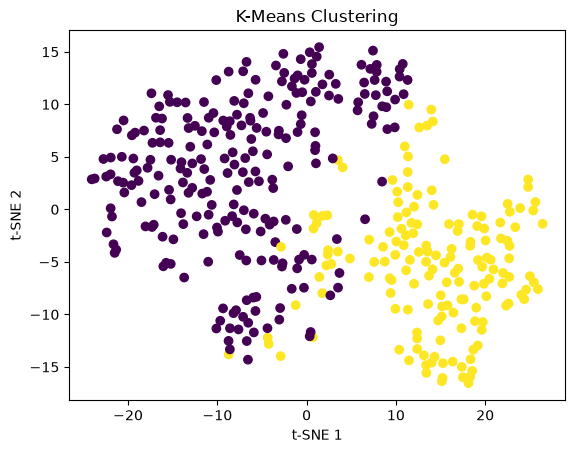

In [11]:
X_scaled = model.named_steps["scaler"].transform(X_data)

tsne_vis = tsne_model(X_scaled)

plt.scatter(tsne_vis[: , 0], tsne_vis[: , 1] , c = labels)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('K-Means Clustering')

#### Clustering Interpratation

In [12]:
df_exp = df.copy()
df_exp['labels'] = labels

In [18]:
cluster_profile = (df_exp.groupby('labels')[features].agg(['mean', 'median']))
cluster_profile

Fresh                Milk             Grocery              Frozen  \
            mean    median      mean    median      mean    median      mean   
labels                                                                         
0       9.122769  9.250138  7.543555  7.558517  7.777696  7.786136  7.706119   
1       8.639757  8.727521  8.980378  8.938791  9.364116  9.312354  7.012352   

                 Detergents_Paper           Delicassen            
          median             mean    median       mean    median  
labels                                                            
0       7.734996         5.784741  5.857933   6.591871  6.655440  
1       7.050980         8.288955  8.401537   7.139150  7.312117

#### Count of customers in clusters

In [20]:
cluster_size = df_exp['labels'].value_counts().sort_index()
cluster_size

labels
0    237
1    158
Name: count, dtype: int64

#### Percentage of cluster labels relative to the Region

In [22]:
pd.crosstab(df_exp['labels'], df_exp['Region'], normalize= 'index')

Region,1,2,3
labels,,,
0,0.198312,0.113924,0.687764
1,0.164557,0.101266,0.734177


#### Percentage of cluster labels relative to the Channels

In [24]:
pd.crosstab(df_exp['labels'], df_exp['Channel'], normalize="index")

Channel,1,2
labels,,
0,0.962025,0.037975
1,0.284810,0.715190


#### Cluster profile with Z-Score, it shows the different between cluster mean and overal mean for any features

In [32]:
df_Z = pd.DataFrame(index=sorted(df_exp['labels'].unique()))

for feature in features:
    cluster_mean = df_exp.groupby('labels')[feature].mean()
    overall_mean = df_exp[feature].mean()
    overall_std = df_exp[feature].std()
    
    df_Z[feature] = (cluster_mean - overall_mean) / overall_std

df_Z

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.172808,-0.575357,-0.628073,0.247172,-0.624601,-0.219114
1,-0.259212,0.863036,0.942110,-0.370758,0.936901,0.328671


#### Shwoing the pattern using heatmap

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

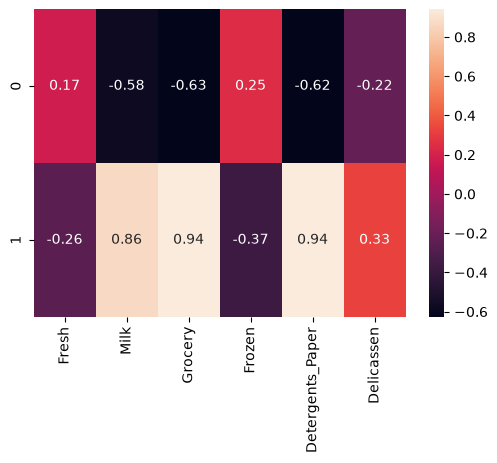

In [37]:
plt.figure(figsize= (6 , 4))

sns.heatmap(data= df_Z, annot= True, fmt= '.2f')

plt.show()

## Conclusion

After evaluating K-Means with different numbers of clusters, the best result was obtained with **K = 2**, achieving a **Silhouette Score of 0.2897**.

This score indicates a relatively weak-to-moderate separation between the clusters. Therefore, while K-Means was able to identify some structure in the dataset, the resulting clusters are not strongly separated.

For this reason, the current K-Means model will be considered as a **baseline** for comparison with other clustering approaches. In the next stages, **Hierarchical Clustering** and **DBSCAN** will be evaluated. Additionally, K-Means, Hierarchical and DBSCAN will be applied after **PCA** to investigate whether dimensionality reduction can improve the clustering structure and evaluation metrics.

In any case, the results derived from the **K-Means algorithm** in this notebook **(without employing dimensionality reduction techniques)** indicate the presence of `two` clusters, comprising `237` and `158` customers, respectively; this means that `60%` of the customers fall into the first group and `40%` into the second

The first group purchased `Fresh` and `Frozen` products more frequently than the second group.

An analysis based on **region** reveals that customers from regions `1` and `2` predominantly fall into the **first group**, whereas those from region `3` are mostly in the **second group**. Similarly, the majority of customers with `Channel 1` are in the **first group**, while the majority of those with `Channel 2` are in the **second group**.

Purchasing patterns for the products, broken down by cluster, are also presented.

| Cluster | Fresh     | Milk      | Grocery   | Frozen    | Detergents_Paper | Delicassen |
|---------|-----------|-----------|-----------|-----------|------------------|------------|
| 0       | 0.172808  | -0.575357 | -0.628073 | 0.247172  | -0.624601        | -0.219114  |
| 1       | -0.259212 | 0.863036  | 0.942110  | -0.370758 | 0.936901         | 0.328671   | 
